# Apples-vs-apples PPC: pz1 vs tree-implied on the current pool_3s baseline

**Date**: 2026-04-29 (week 8 prep) · **Stance focus**: Global Workspace Theory · **Fit**: `three_state_pooled_soft_anchored.nc` (pool_3s with soft Beta(50,1) / Beta(1,50) anchors)

This notebook redoes the pz1-vs-tree-implied stratified PPC comparison from notebook 14 — but on the *current* baseline (three-state leaf + label-pooled tree prior + soft anchors), which is `pool_3s` per the week 7 report.

## Why this matters

The default per-(expert, system) PPC uses `indicator_prob_source="pz1"` — the *data-conditioned leaf-updated* posterior $P(z_j = 1 \mid \text{ratings for indicator } j, \theta)$. Per-indicator rating evidence dominates the sigmoid so $\text{pz1}_j$ localises sharply to ~0 or ~1 regardless of what the tree said. The PPC then resamples ratings from a mixture weighted by `pz1`, so it largely confirms the *emission layer* is flexible — it doesn't probe the tree.

The tree-implied source (`indicator_prob_source="tree_implied"` / `"q"`) uses raw $q_j$ as the mixture weight. **That** is the structural test of whether the tree adequately drives cross-system ratings from $C$. Per the arvo notes (Apr 27 §1) the prior-predictive transmission is only ~5% of the root anchor gap, so we expect this PPC to substantially under-predict at the anchor cells.

## What's compared

Same posterior, two PPC sources, same plotting code (`plot_per_expert_system_histograms`).

In [1]:
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
os.chdir(REPO_ROOT)

from pool_3s_pz1_vs_tree_implied import (
    run,
    focus_cell_comparison_table,
    global_metric_table,
)

## Run

Loads the saved fit, rebuilds processor + builder (no sampling — `build_model` is graph-only), computes both PPCs, prints summary tables, and saves the two grids to `report_figures/`.

In [2]:
results = run(
    nc_filename="three_state_pooled_soft_anchored.nc",
    n_draws=500,
    save_figs=True,
    fig_tag="pool_3s_soft",
)

Loading fit: /Users/ryankelly/ryan-code/research/dcm-code/results/gwt_tree_pooling/three_state_pooled_soft_anchored.nc


Loaded three_state_pooled_soft_anchored.nc.
Posterior shape: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 2000, 'kappa_dim_0': 6}); 6 experts, 76 nodes.
Computing pz1 (default leaf-updated) PPC...


Computing tree-implied (q) PPC...



=== Global obs-weighted |Δ| metrics ===
Source            |Δmean|   |Δextreme|    |Δleft|   |Δright|
------------------------------------------------------------
pz1                 0.467        0.125      0.076      0.070
tree_implied        1.063        0.276      0.227      0.166

=== Focus-cell comparison ===
Cell                             obs_m pz1_pred_m tree_pred_m  obs_ex pz1_pred_ex tree_pred_ex
----------------------------------------------------------------------------------------------------
Derek Shiller x Human             5.78       5.30        3.94    0.86        0.72         0.57
Derek Shiller x ELIZA             0.14       0.97        3.07    0.98        0.73         0.55
Rachael Miller x Chicken          4.22       3.98        3.38    0.15        0.37         0.55
Luhan Mikaelson x LLMs            3.71       3.34        3.21    0.17        0.36         0.55


Saved /Users/ryankelly/ryan-code/research/dcm-code/report_figures/pool_3s_soft_pz1_ppc_strat.png
Saved /Users/ryankelly/ryan-code/research/dcm-code/report_figures/pool_3s_soft_tree_implied_ppc_strat.png


## Summary tables (re-print)

Re-printed here with the in-notebook results for sharing.

In [3]:
print("=== Global obs-weighted |Δ| metrics ===")
print(global_metric_table(results["ppc_pz1"], results["ppc_tree"]))
print()
print("=== Focus-cell comparison ===")
print(focus_cell_comparison_table(results["ppc_pz1"], results["ppc_tree"]))

=== Global obs-weighted |Δ| metrics ===
Source            |Δmean|   |Δextreme|    |Δleft|   |Δright|
------------------------------------------------------------
pz1                 0.467        0.125      0.076      0.070
tree_implied        1.063        0.276      0.227      0.166

=== Focus-cell comparison ===
Cell                             obs_m pz1_pred_m tree_pred_m  obs_ex pz1_pred_ex tree_pred_ex
----------------------------------------------------------------------------------------------------
Derek Shiller x Human             5.78       5.30        3.94    0.86        0.72         0.57
Derek Shiller x ELIZA             0.14       0.97        3.07    0.98        0.73         0.55
Rachael Miller x Chicken          4.22       3.98        3.38    0.15        0.37         0.55
Luhan Mikaelson x LLMs            3.71       3.34        3.21    0.17        0.36         0.55


## Stratified grids

Grids saved to `report_figures/pool_3s_soft_pz1_ppc_strat.png` and `report_figures/pool_3s_soft_tree_implied_ppc_strat.png`. Same row/column layout (experts × systems); only the indicator-probability source differs.


--- pz1 ---


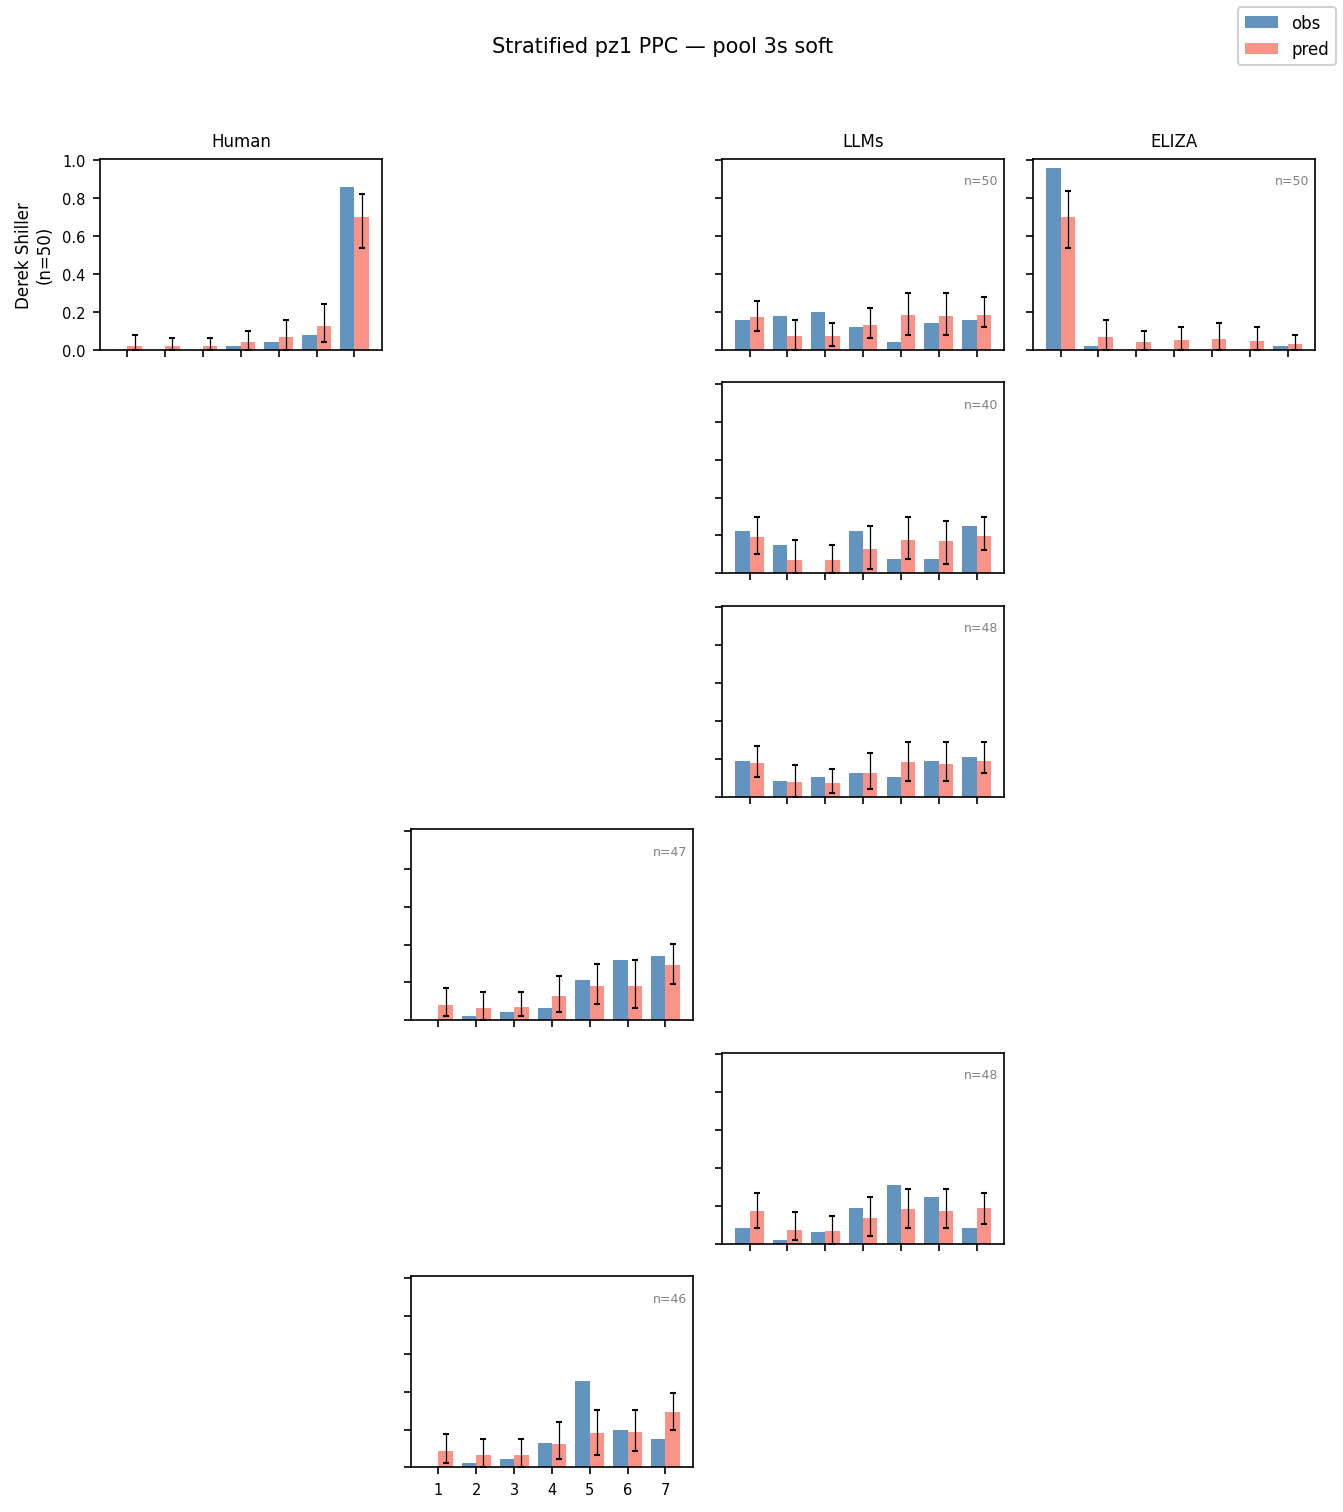


--- tree_implied ---


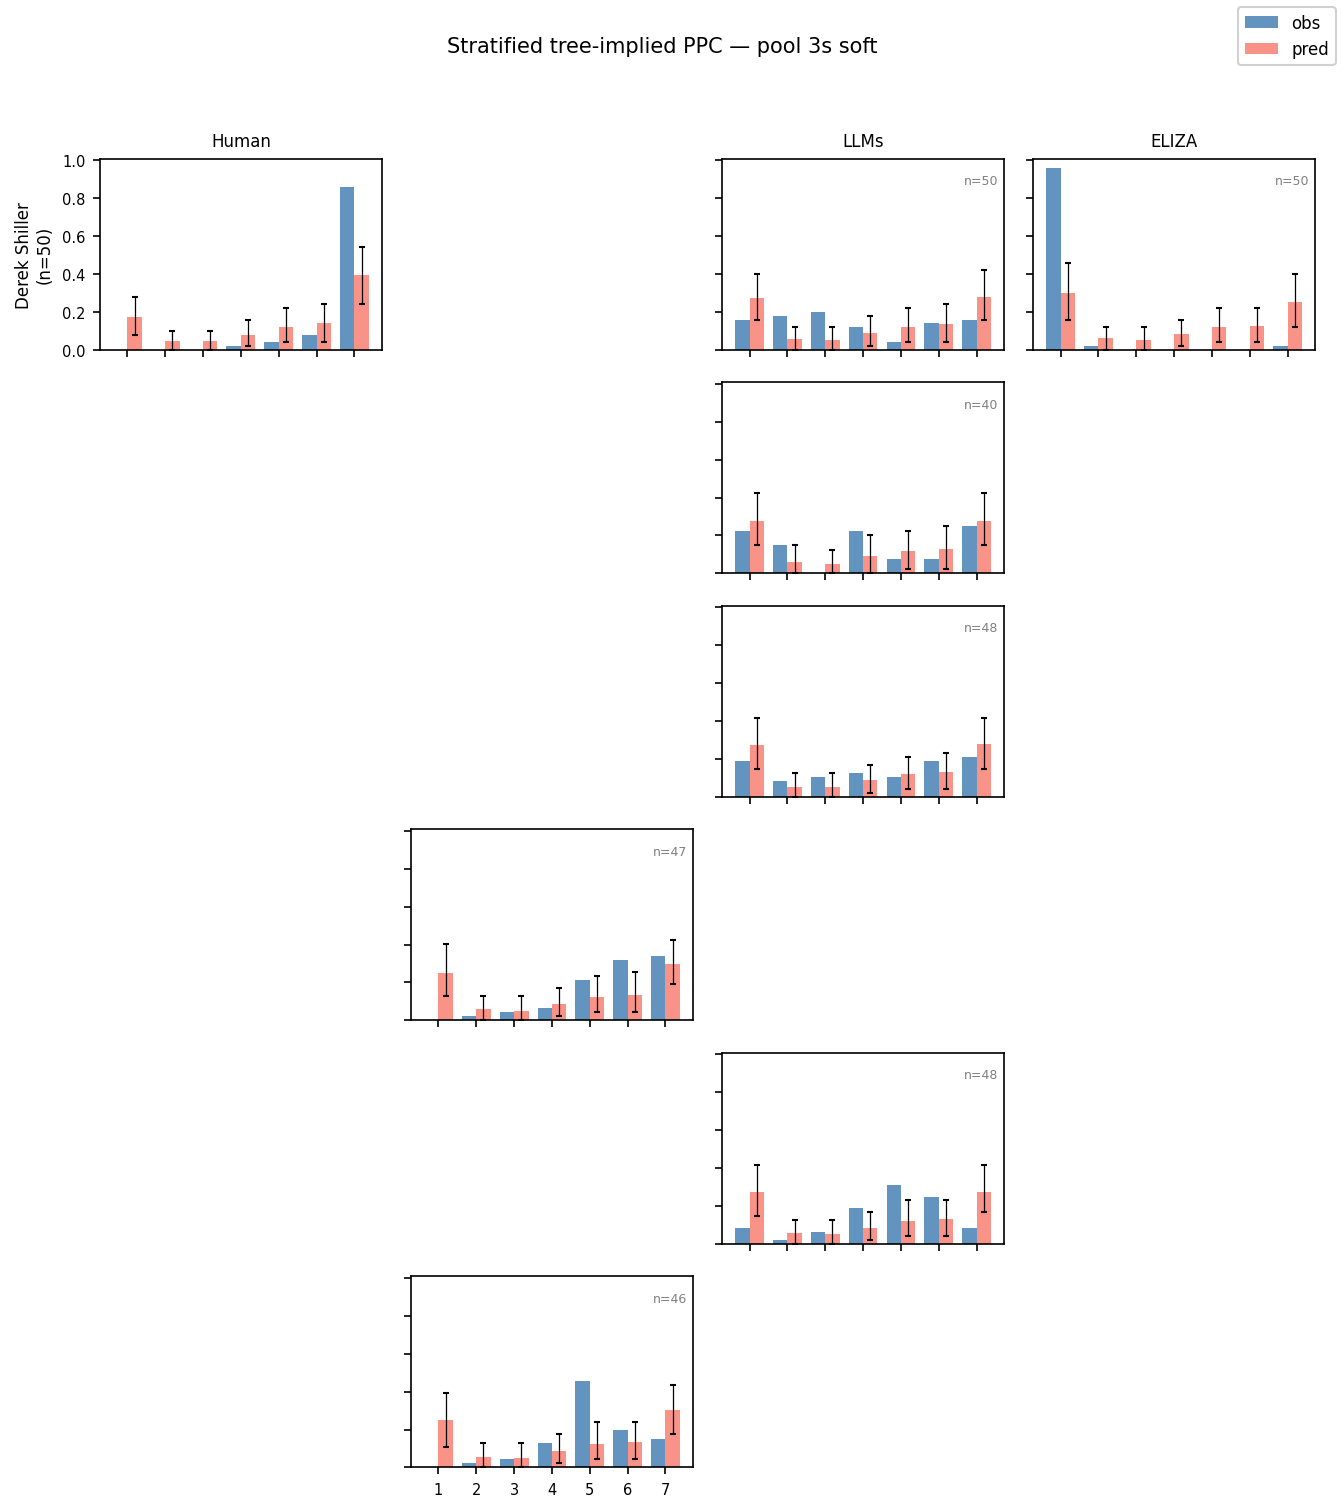

In [4]:
from IPython.display import Image, display

for source_label in ["pz1", "tree_implied"]:
    print(f"\n--- {source_label} ---")
    display(
        Image(filename=f"report_figures/pool_3s_soft_{source_label}_ppc_strat.png")
    )

## Read of the result

- **pz1 PPC** mostly tracks observed: Human r=7 mass (~0.86 obs vs ~0.70 pred), ELIZA r=1 mass (~0.95 obs vs ~0.70 pred), Chicken / LLM cells reasonable. The remaining gap is the documented emission ceiling (~0.08 on ELIZA per week 7).
- **Tree-implied PPC** falls apart at the anchor cells: predicted distributions are nearly *flat* across ratings 1–7 even when observed ratings are extremely concentrated. Mean predicted rating for Derek × Human is **3.94** (obs 5.78); for Derek × ELIZA is **3.07** (obs 0.14). This is the ~5% transmission story made visible — the tree alone cannot push extreme rating concentration; only the per-indicator Bayes update via `pz1` can.
- **Global obs-weighted |Δ|**: pz1 ≈ 0.47 mean / 0.13 extreme; tree-implied ≈ 1.06 mean / 0.28 extreme. Tree-implied is ~2.2× worse on every summary, with the extra error concentrated at the anchor cells.

Implication: the weekly-report PPCs that "look pretty decent" are largely a check on the rating-emission layer given a data-fitted latent state. The tree's structural attenuation is fully consistent with — and only visible under — the tree-implied PPC.